In [1]:
import kagglehub
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

In [2]:
!mkdir -p ~/.kaggle && echo KGAT_7d3d8b9d02289ce21e300dd13afac570 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token
# знаю что ключ палю, но мне пофиг)

In [3]:
path = kagglehub.competition_download('dog-breed-identification')

print("Path to competition files:", path)
# path = '/Users/ilonakazanceva/.cache/kagglehub/competitions/dog-breed-identification'
print(os.listdir(path))
labels = pd.read_csv(f"{path}/labels.csv")
print(labels.head())

100%|██████████| 691M/691M [00:03<00:00, 187MB/s]  

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/dog-breed-identification
['sample_submission.csv', 'train', 'labels.csv', 'test']
                                 id             breed
0  000bec180eb18c7604dcecc8fe0dba07       boston_bull
1  001513dfcb2ffafc82cccf4d8bbaba97             dingo
2  001cdf01b096e06d78e9e5112d419397          pekinese
3  00214f311d5d2247d5dfe4fe24b2303d          bluetick
4  0021f9ceb3235effd7fcde7f7538ed62  golden_retriever


In [4]:
train_path = os.path.join(path, "train")
test_path = os.path.join(path, "test")
print(train_path)
print(test_path)

/root/.cache/kagglehub/competitions/dog-breed-identification/train
/root/.cache/kagglehub/competitions/dog-breed-identification/test


In [5]:
#collecting full paths to images
train = []
for root, dirs, files in os.walk(train_path):
    for file in files:
        full_path = os.path.join(root, file)
        train.append(full_path)
print(len(train))
print(*train[:10], sep='\n')

10222
/root/.cache/kagglehub/competitions/dog-breed-identification/train/819f97c27a2f46f36a88d1e1cecd8e0a.jpg
/root/.cache/kagglehub/competitions/dog-breed-identification/train/bc408c0d39c5c9c8e184d83c45ff891a.jpg
/root/.cache/kagglehub/competitions/dog-breed-identification/train/f52a0aaff41a517be216bf41c967a751.jpg
/root/.cache/kagglehub/competitions/dog-breed-identification/train/9802d488e7a0b8b4fb04bfe2af2361f9.jpg
/root/.cache/kagglehub/competitions/dog-breed-identification/train/4f2d37638e34d2e896c74bbfe9bd049d.jpg
/root/.cache/kagglehub/competitions/dog-breed-identification/train/269a6aeefd8050aafda02044c9cd2a80.jpg
/root/.cache/kagglehub/competitions/dog-breed-identification/train/9e7db8711f479dfa968b2297bee33104.jpg
/root/.cache/kagglehub/competitions/dog-breed-identification/train/a6951e4f0cff9c000f2f112043abb085.jpg
/root/.cache/kagglehub/competitions/dog-breed-identification/train/f069ed4df76d788ff43403f1ba4fa4a8.jpg
/root/.cache/kagglehub/competitions/dog-breed-identificati

(np.float64(-0.5), np.float64(374.5), np.float64(499.5), np.float64(-0.5))

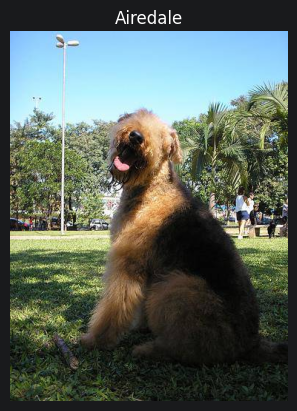

In [6]:
#это фан ячейка
i=3
img=Image.open(train[i])
img_path = train[i]
img_id = os.path.splitext(os.path.basename(img_path))[0]
plt.imshow(img)
plt.title(" ".join(labels.loc[labels['id']==img_id, "breed"].values[0].split("_")).title())
plt.axis("off")

In [7]:
encoder = LabelEncoder()
labels['breed_encoded'] = encoder.fit_transform(labels['breed']) #если дальше будем пользоваться softmax на выходе
labels.head()
labels.columns

Index(['id', 'breed', 'breed_encoded'], dtype='object')

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),
    transforms.RandomHorizontalFlip(),  # аугментация только для train
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [9]:
class DogDataset(Dataset): #именно такие три функции из документации по датасетам
    def __init__(self, file_paths, labels, transform=None): #трансформ это из предыдущей ячейки преобразования над картинкой    
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform
    def __getitem__(self, i):
        img_path = self.file_paths[i]
        img_id = os.path.splitext(os.path.basename(img_path))[0]
        img = Image.open(img_path).convert('RGB') #перестраховочка от греха подальше
        if self.transform:
            img = self.transform(img)
        label = self.labels.loc[self.labels['id']==img_id, "breed_encoded"].values[0]
        return img, label
    def __len__(self):
        return len(self.file_paths)

In [10]:
path_to_label = dict(zip(labels['id'], labels['breed_encoded']))
train_labels_for_split = [path_to_label[os.path.splitext(os.path.basename(img_path))[0]] for img_path in train]

train_paths, val_paths = train_test_split(
    train,
    test_size=0.2,
    random_state=42,
    stratify=train_labels_for_split
)
train_dataset = DogDataset(train_paths, labels, transform=train_transform) #делает датасет
val_dataset = DogDataset(val_paths, labels, transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) #делает итератор над датасетом
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)
print(len(train_dataset), len(val_dataset))

8177 2045


In [11]:
NUM_CLASSES = len(labels['breed'].unique())
model = models.mobilenet_v3_large(weights='IMAGENET1K_V1') #модель уже обучена на ImageNet, но там 1000 классов
print(model)
print(model.classifier)
#in_features - сколько вход у оригинального последнего слоя 
model.classifier[3] = nn.Linear(model.classifier[3].in_features, NUM_CLASSES) #меням на последнем слое, что у нас num_classes классов

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 142MB/s]


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

In [ ]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(device)

for param in model.features[-3:].parameters(): #обучается только голова. так можно сделать, потому что модель уже обучена на imagenet и features уже умеют извлекать признаки
    param.requires_grad = True

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001) #оставляем только последние три, у которых requires_grad=True

best_val_loss = float('inf')
patience = 10
min_delta = 0.001
patience_counter = 0
best_weights = None
for epoch in range(50):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels_batch in train_loader:
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() #item переводит тензор в число
        predicted = outputs.argmax(dim=1) #порода, dim1 -  ищем максимум по столбцам
        correct += (predicted == labels_batch).sum().item()
        total += labels_batch.size(0)
    
    train_loss = total_loss / len(train_loader)
    train_acc = correct / total * 100

    model.eval() #переключаем модель в режим инференса 
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels_batch in val_loader:
            images = images.to(device)
            labels_batch = labels_batch.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels_batch)

            val_loss += loss.item() #item переводит тензор в число
            predicted = outputs.argmax(dim=1) #порода, dim1 -  ищем максимум по столбцам
            val_correct += (predicted == labels_batch).sum().item()
            val_total += labels_batch.size(0)
    
    val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total * 100


    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}, Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.2f}")

    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        patience_counter = 0
        best_weights = model.state_dict().copy()
        print('val улучшился, сохранили веса')
    else:
        patience_counter += 1
        print('нет улучшения')
        if patience_counter >= patience:
            print(f'early stopping на эпохе {epoch+1}')
            model.load_state_dict(best_weights)
            break

cuda
Epoch 1, Train Loss: 3.5933, Train Accuracy: 22.16, Validation Loss: 1.8504, Validation Accuracy: 55.55
val улучшился, сохранили веса
Epoch 2, Train Loss: 1.5293, Train Accuracy: 59.31, Validation Loss: 1.0856, Validation Accuracy: 67.92
val улучшился, сохранили веса
Epoch 3, Train Loss: 1.0173, Train Accuracy: 70.77, Validation Loss: 0.9182, Validation Accuracy: 72.37
val улучшился, сохранили веса
Epoch 4, Train Loss: 0.7614, Train Accuracy: 77.94, Validation Loss: 0.8572, Validation Accuracy: 74.38
val улучшился, сохранили веса
Epoch 5, Train Loss: 0.6046, Train Accuracy: 81.77, Validation Loss: 0.7906, Validation Accuracy: 75.79
val улучшился, сохранили веса
Epoch 6, Train Loss: 0.4823, Train Accuracy: 85.73, Validation Loss: 0.8382, Validation Accuracy: 73.89
нет улучшения
Epoch 7, Train Loss: 0.3745, Train Accuracy: 89.36, Validation Loss: 0.8447, Validation Accuracy: 74.33
нет улучшения
Epoch 8, Train Loss: 0.3160, Train Accuracy: 90.97, Validation Loss: 0.8439, Validation A